# Galaxy Bias Analysis: P-Millennium GALFORM Snapshots

Investigate galaxy clustering bias by comparing galaxy and dark matter two-point correlation functions across P-Millennium merger tree subvolumes.

In [6]:
# Ensure local package path is first
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)


# Now import libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from utils.matplotlib_config import register_matplotlib_setconfig
from config import get_base_dir, set_base_dir

# Import functions
from analysis.correlation import (
    compute_galaxy_bias,
    avg_galaxy_bias_over_subvolumes,
)

# Set the correct base directory
set_base_dir('/cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16')
base_dir = get_base_dir()
register_matplotlib_setconfig(mpl)
mpl.setconfig()

# Plotting defaults
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## Single Subvolume Example

In [7]:
# Parameters for analysis
example_snapshot = 'iz207'
example_ivol = 180
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply minimum halo mass cut
mhalo_min = 1e11  # Msun

result = compute_galaxy_bias(
    iz_path=snap_path,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    centrals_only=False,  # All galaxies (centrals + satellites)
    mhalo_min=mhalo_min,
)

if result is not None:
    z = result.attrs.get('z')
    ngal = result.attrs.get('ngal')
    nhalo = result.attrs.get('nhalo')
    z_str = f"{z:.4f}" if z is not None else "N/A"
    ratio_str = f"{ngal / nhalo:.2f}" if (ngal is not None and nhalo is not None and nhalo > 0) else "N/A"
    print(f"Redshift: {z_str}")
    print(f"N_galaxies (all): {ngal}")
    print(f"N_halos (DM centers): {nhalo}")
    print(f"Galaxies per halo: {ratio_str}")
else:
    print(f"Failed to compute galaxy bias for {example_snapshot}, ivol={example_ivol}")

Redshift: N/A
N_galaxies (all): 4124
N_halos (DM centers): 5305
Galaxies per halo: 0.78



   r [Mpc/h]      ξ_gal(r)       ξ_DM(r)      bias
--------------------------------------------------
        0.13  24146.077951  21075.986373     1.070
        0.17  22124.423738  21269.615064     1.020
        0.23  20355.800351  19590.031211     1.019
        0.32  16390.571338  14515.255650     1.063
        0.44   9903.921703   8096.911931     1.106
        0.60   4525.798140   3742.294219     1.100
        0.84   1844.673191   1671.973843     1.050
        1.17    816.367913    766.016045     1.032
        1.63    404.721976    350.961442     1.074
        2.26    154.216839    143.009225     1.038
        3.11     60.560836     55.022558     1.049
        4.26     14.420390     15.240532     0.973
        5.89      1.229502      1.781840     0.831
        8.65      0.493442      0.491643     1.002
       11.84      0.189219      0.170840     1.052
       16.40      0.085064      0.073544     1.075
       22.87      0.159455      0.121768     1.144
       31.56      0.006403    

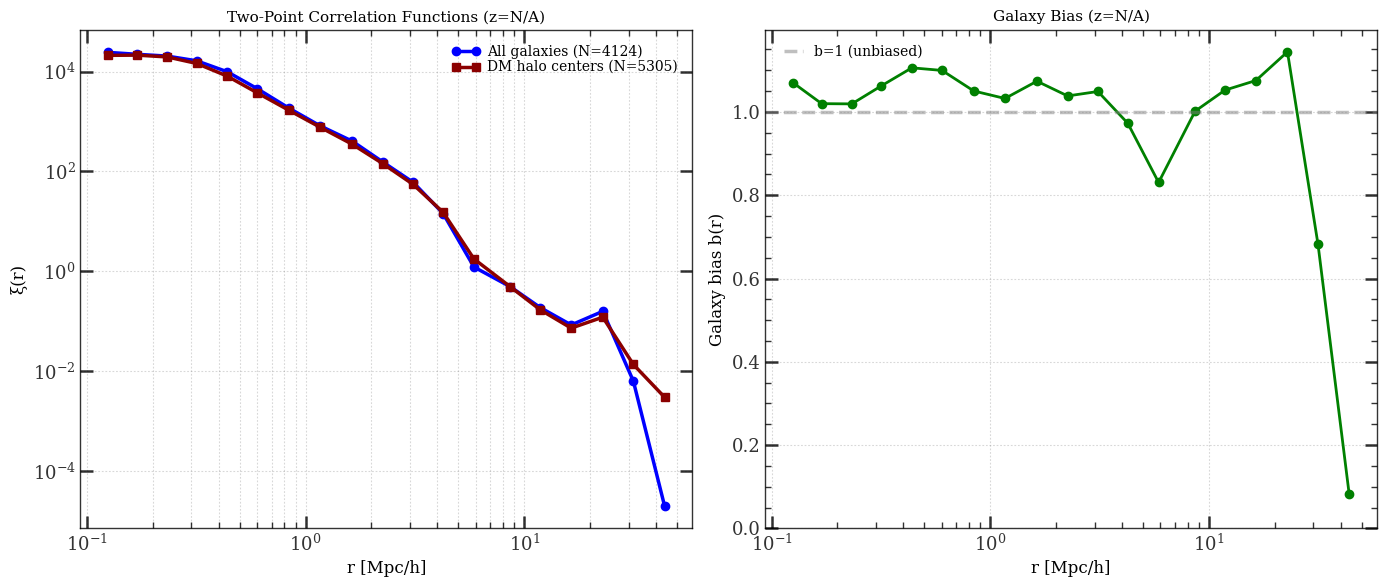

In [10]:
if result is not None:
    r = result['r'].to_numpy()
    xi_gal = result['xi_gal'].to_numpy()  # Already xi (not 1+xi)
    xi_dm = result['xi_dm'].to_numpy()

    # Compute bias correctly: b(r) = sqrt(xi_gal / xi_dm)
    bias = np.full_like(xi_gal, np.nan)
    mask = (xi_gal > 0) & (xi_dm > 0)
    bias[mask] = np.sqrt(xi_gal[mask] / xi_dm[mask])

    # Create summary table
    print(f"\n{'r [Mpc/h]':>12}  {'ξ_gal(r)':>12}  {'ξ_DM(r)':>12}  {'bias':>8}")
    print("-" * 50)
    for i in range(len(r)):
        if np.isfinite(bias[i]):
            print(f"{r[i]:12.2f}  {xi_gal[i]:12.6f}  {xi_dm[i]:12.6f}  {bias[i]:8.3f}")

    # Get z for formatting
    z = result.attrs.get('z')
    z_str = f"{z:.2f}" if z is not None else "N/A"

    # Two-panel plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Correlation functions (only positive values for log-log)
    ax = axes[0]
    gal_mask = np.isfinite(xi_gal) & (xi_gal > 0)
    dm_mask = np.isfinite(xi_dm) & (xi_dm > 0)
    ax.loglog(r[gal_mask], xi_gal[gal_mask], 'o-', color='blue',
                    label=f'All galaxies (N={result.attrs.get("ngal")})', markersize=6)
    ax.loglog(r[dm_mask], xi_dm[dm_mask], 's-', color='darkred',
                    label=f'DM halo centers (N={result.attrs.get("nhalo")})', markersize=6)
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('ξ(r)', fontsize=12)
    ax.set_title(f'Two-Point Correlation Functions (z={z_str})', fontsize=11)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=10)

    # Right: Galaxy bias
    ax = axes[1]
    ax.semilogx(r[mask], bias[mask], 'o-', color='green', markersize=6, linewidth=2)
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('Galaxy bias b(r)', fontsize=12)
    ax.set_title(f'Galaxy Bias (z={z_str})', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
else:
    print("Cannot compute galaxy bias: result is None")

## Averaged Over Multiple Subvolumes

In [13]:
# Fetch average galaxy bias data over multiple subvolumes
example_snapshot = 'iz207'
snap_path = str(base_dir / example_snapshot)
example_ivols = [40, 60, 100]  # Multiple subvolumes

avg_result = avg_galaxy_bias_over_subvolumes(
    iz_path=snap_path,
    ivols=example_ivols,
    rbins=rbins,
    nthreads=4,
    centrals_only=False,  # All galaxies
    mhalo_min=mhalo_min,
)

if avg_result is not None:
    z = avg_result.attrs.get('z')
    z_str = f"{z:.4f}" if z is not None else "N/A"
    n_used = avg_result.attrs.get('n_used')
    n_requested = avg_result.attrs.get('n_requested')
    print(f"Redshift: {z_str}")
    print(f"Subvolumes successful: {n_used}/{n_requested}")
else:
    print("Failed to compute average galaxy bias")

Redshift: N/A
Subvolumes successful: 3/3



   r [Mpc/h]        bias         std
-----------------------------------
        0.12       1.034       0.037
        0.17       0.902       0.060
        0.24       1.067       0.043
        0.32       1.061       0.007
        0.44       1.069       0.021
        0.61       1.090       0.019
        0.85       1.080       0.005
        1.17       1.066       0.017
        1.64       1.050       0.027
        2.25       1.048       0.028
        3.13       1.002       0.057
        4.34       0.961       0.028
        5.93       0.963       0.105
        8.20       0.951       0.035
       11.59       1.002       0.033
       16.28       0.890       0.082
       22.65       0.956       0.267
       31.61       1.033       0.154
       43.67       0.997       0.229


TypeError: unsupported format string passed to NoneType.__format__

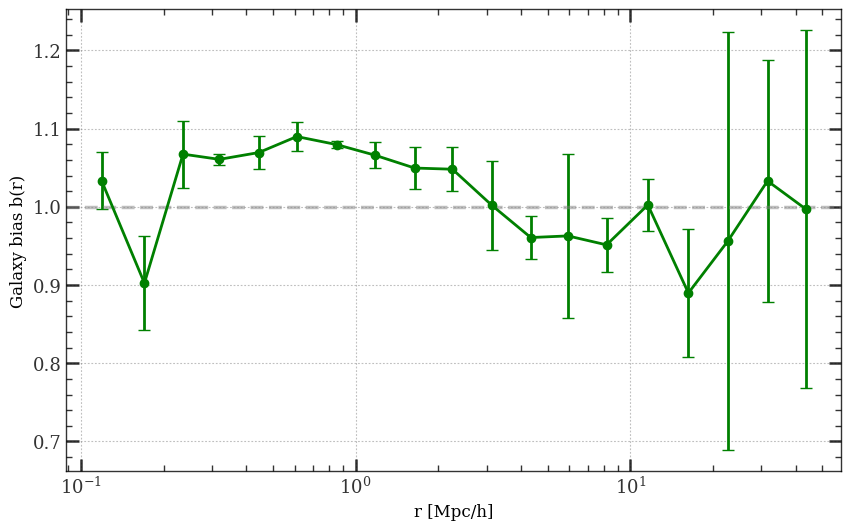

In [ ]:
if avg_result is not None:
    r = avg_result['r'].to_numpy()
    xi_gal = avg_result['xi_gal'].to_numpy()
    xi_dm = avg_result['xi_dm'].to_numpy()

    # Compute bias correctly: b(r) = sqrt(xi_gal / xi_dm)
    bias = np.full_like(xi_gal, np.nan)
    mask = (xi_gal > 0) & (xi_dm > 0)
    bias[mask] = np.sqrt(xi_gal[mask] / xi_dm[mask])
    bias_std = avg_result['bias_std'].to_numpy()

    # Create summary table
    print(f"\n{'r [Mpc/h]':>12}  {'bias':>10}  {'std':>10}")
    print("-" * 35)
    for i in range(len(r)):
        if mask[i]:
            print(f"{r[i]:12.2f}  {bias[i]:10.3f}  {bias_std[i]:10.3f}")

    # Get z for formatting
    z = avg_result.attrs.get('z')
    z_str = f"{z:.2f}" if z is not None else "N/A"
    n_used = avg_result.attrs.get('n_used')

    # Plot with error bars
    plt.figure(figsize=(10, 6))
    plt.errorbar(r[mask], bias[mask], yerr=bias_std[mask], 
                    fmt='o-', color='green', markersize=6, linewidth=2,
                    capsize=4, label=f'Mean bias (N={n_used} subvolumes)')
    plt.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    plt.xscale('log')
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('Galaxy bias b(r)', fontsize=12)
    plt.title(f'Average Galaxy Bias (z={z_str})', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: avg_result is None")

## Redshift Evolution

In [ ]:
# Fetch galaxy bias data at multiple redshifts
iz_nums = [207]
example_ivol = 100

redshift_results = []
for iz_num in iz_nums:
    snap_path = str(base_dir / f'iz{iz_num}')
    try:
        res = compute_galaxy_bias(
            iz_path=snap_path,
            ivol=example_ivol,
            rbins=rbins,
            nthreads=4,
            centrals_only=False,  # All galaxies
            mhalo_min=mhalo_min,
        )
        
        if res is not None:
            z = res.attrs.get('z')
            ngal = res.attrs.get('ngal')
            nhalo = res.attrs.get('nhalo')
            redshift_results.append(res)
            z_str = f"{z:.3f}" if z is not None else "N/A"
            print(f"iz{iz_num}: z={z_str}, N_gal={ngal}, N_halo={nhalo}")
        else:
            print(f"iz{iz_num}: Failed to compute galaxy bias")
    
    except Exception as e:
        print(f"iz{iz_num}: Error: {e}")

print(f"Successfully computed {len(redshift_results)} snapshot(s)")

In [ ]:
if redshift_results:
    plt.figure(figsize=(10, 6))

    colors = ['#d62728', '#1f77b4']
    linestyles = ['-', '--']
    markers = ['o', 's']

    for i, res in enumerate(redshift_results):
        r = res["r"].to_numpy()
        xi_gal = res["xi_gal"].to_numpy()  # Already xi (not 1+xi)
        xi_dm = res["xi_dm"].to_numpy()
        
        # Compute bias correctly: b(r) = sqrt(xi_gal / xi_dm)
        bias = np.sqrt(xi_gal / xi_dm)
        mask = np.isfinite(bias)
        z = res.attrs.get("z")
        label = f"z={z:.2f}" if z is not None else "z=unknown"
        
        plt.semilogx(r[mask], bias[mask], linestyle=linestyles[i], marker=markers[i],
                        color=colors[i], label=label, markersize=6, linewidth=2.5, alpha=0.8)

    plt.axhline(1, color='gray', linestyle=':', alpha=0.6, linewidth=1.5)
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('Galaxy bias b(r)', fontsize=12)
    plt.title('Galaxy Bias: z=0 vs z≈0.5', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11, loc='best')
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: no redshift results available")